### Objetivos do Notebook

Notebook reponsável por extrair a tabela de origem ssi_fato_eventos_esocial do datamart de SSI  armazenadas no sistema S+ e salvar esses dados no formato Parquet no bucket bronze do MinIO.

### Data Owner
Rodrigo Souza - rodrigo.souza@sfiemt.ind.br

### Horário de execução do Notebook
Não executado



### Origens extraídas do S+
As seguintes tabelas serão extraídas do sistema S+:

- **ssi_fato_eventos_esocial**

### Local de destino no bucket bronze
Os datasets resultantes gerados pela extração do notebook serão armazenados no bucket bronze do MinIO no formato Parquet, seguindo a estrutura de diretórios e nomes de arquivos baseados na data de execução do notebook.

- **ssi_fato_eventos_esocial:** bronze/ssi/smais/ssi_fato_eventos_esocial/{data_execucao}/ssi_fato_eventos_esocial_{data_execucao}.parquet

### Linhagem de dados
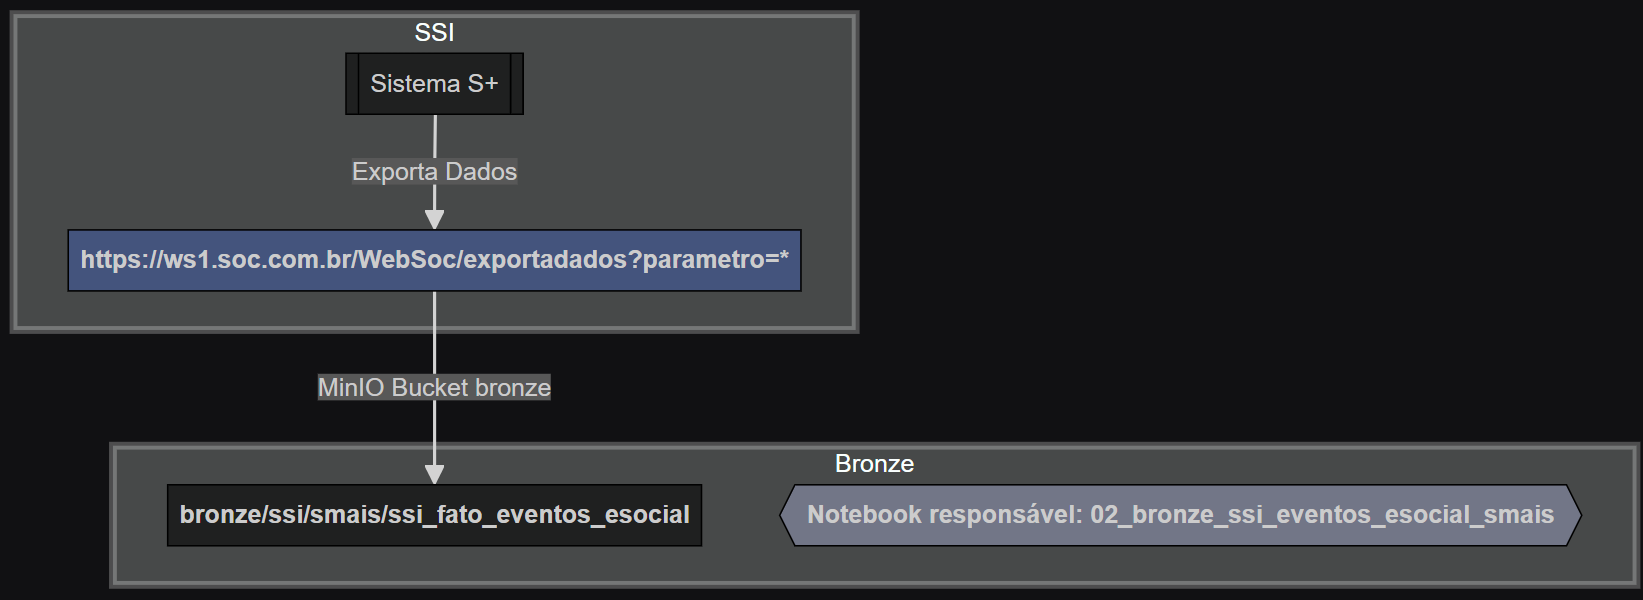

# Bibliotecas necessárias

In [1]:
# import os
# import warnings
# import pandas as pd
# from util.SSIExportas import Exporta
# from util.SSIUtils import get_df_unidade,  insert_datalake #Realiza leitura do csv em /tmp
# from datetime import datetime, timedelta
# from util.SSICalendarios import calendario_ano
# import json
# warnings.filterwarnings("ignore")

# Definição do período de busca na API

In [2]:
# Gera calendario automaticamente
# def gerar_calendario(dias):
#     # Calcular a data de fim (hoje)
#     data_fim = datetime.now()
    
#     # Calcular a data de início
#     data_inicio = data_fim - timedelta(days=dias-1)
    
#     return {'1': {'dataInicio': data_inicio.strftime("%d/%m/%Y"), 
#                   'dataFim': data_fim.strftime("%d/%m/%Y")}}

# # Exemplo: gerar calendário com os últimos 5 dias
# calendario = gerar_calendario(5)

# calendario = calendario_ano

# Obtendo credenciais da API para eventos do e-Social

In [3]:
# # Converter a string JSON em uma lista de Python
# cadastro_empresas_credentials = os.getenv('EVENTOS_ESOCIAL_CREDENTIALS')
# exporta_credentials = json.loads(cadastro_empresas_credentials)

# Realizando buscas na API para cada empresa em cada unidade

In [ ]:
# frames = []
# for exporta in exporta_credentials:
#     #Retorna unidade da lista exporta_configs
#     unidade = exporta["unidade"]
#     #Retorna cod_exporta da lista exporta_configs
#     cod_exporta = exporta["cod_exporta"]
#     #Retorna chave_exporta da lista exporta_configs
#     chave_exporta = exporta["chave_exporta"]

#     # Instancia função Exporta (passando unidade, codigo, chave)
#     EXPORTA = Exporta(unidade=unidade, codigo=cod_exporta, chave=chave_exporta)

#     # Chama função eventos_esocial de Exporta (Instância da classe ExportaDados com as configurações para exportação dos eventos do eSocial.)
#     UNIDADE = EXPORTA.eventos_esocial()

#     # Chama função get_df_unidade de utils. Obtém um DataFrame com as informações da unidade vinculada especificada. (tmp/empresas.csv).Filtrando pelas unidades especificadas em exporta_credentials (cadastro_de_epi_credentials)
#     df_unidade = get_df_unidade(unidade_vinculada=unidade)

#     for count, empresa in enumerate(df_unidade["CODIGO"], start=1): #Este loop itera sobre cada linha do DataFrame df_unidade e extrai o código de cada empresa
#         count_empresas = len(df_unidade)
#         print(f"Coletando empresa {empresa} da unidade {unidade} : {count}/{count_empresas}")
#         UNIDADE.update_args({"empresaTrabalho": empresa}) #Aqui, os argumentos do objeto UNIDADE são atualizados com o código da empresa em que estamos atualmente iterando.
        
#         for m in calendario.keys(): #Itera sobre as chaves do dicionário 
#             UNIDADE.update_args(calendario[m]) #Os argumentos do objeto UNIDADE são atualizados com base nas informações do calendário
#             try: # Aqui, um DataFrame df é obtido usando o método get_df do objeto UNIDADE, com base em alguns critérios, como a unidade atual (unidade) e o código da empresa (empresa).
#                 df = UNIDADE.get_df(
#                     {"UNIDADEVINCULADA": unidade, "CODIGOEMPRESA": empresa}
#                 )
#             except Exception as e:
#                 print("Erro: ", e)
#             if not df.empty:
#                 frames.append(df)
    

Coletando empresa 818393 da unidade 521194 : 1/605
Coletando empresa 921256 da unidade 521194 : 2/605
Coletando empresa 1704937 da unidade 521194 : 3/605
Coletando empresa 714293 da unidade 521194 : 4/605
Coletando empresa 624527 da unidade 521194 : 5/605
Coletando empresa 701532 da unidade 521194 : 6/605
Coletando empresa 685351 da unidade 521194 : 7/605
Coletando empresa 1261170 da unidade 521194 : 8/605
Coletando empresa 685452 da unidade 521194 : 9/605
Coletando empresa 1522964 da unidade 521194 : 10/605
Coletando empresa 701222 da unidade 521194 : 11/605
Coletando empresa 967395 da unidade 521194 : 12/605
Coletando empresa 716693 da unidade 521194 : 13/605


# Tratamento

In [ ]:
# # Junção dos frames para geração de dataframe final
# df = pd.concat(frames)

In [ ]:
# # Remoção de dados duplicados 
# df = df.drop_duplicates()

In [ ]:
# # Aplica uma função lambda a todas as colunas do DataFrame, exceto nas colunas a ignorar
# df = df.apply(lambda col: col.str.replace(r'\t', '') if col.name and col.dtype == 'object' else col)

# Inserindo no Data Lake

In [ ]:
# insert_datalake(df, 'ssi_fato_eventos_esocial')